# FIFA World Cup 2022 Tweet Sentiment — Reproducibility & Label-Quality Audit

**Single-source, leakage-free, fully reproducible pipeline.**

This notebook produces **every number** used in the manuscript, from one dataset:
`tirendazacademy/fifa-world-cup-2022-tweets`, plus a real 5-annotator label-quality
study.

It runs:
1. Data loading + automatic column detection + merged best-practice cleaning
2. Exploratory data analysis (class balance, token lengths, top words)
3. **Leakage demonstration + control**: trains DT/RF *with* duplicates to show ~99% inflation, then removes duplicates *before* any split and re-trains to show the drop
4. A single stratified 80/20 split (`seed=42`) reused by **every** model
5. Seven classical ML classifiers under **TF-IDF** and **CountVectorizer**, stratified **5-fold CV** + held-out test metrics
6. A **Conv1D–BiLSTM** deep model
7. Three fine-tuned transformers: **BERT, DistilBERT, RoBERTa**
8. Real **inference-latency** timing per model
9. **McNemar's test** for statistical significance between models
10. Real **error analysis** export
11. **Label-quality audit**: reads the completed 5-annotator file, computes Fleiss' κ, pairwise Cohen's κ, and human-vs-CardiffNLP agreement (the paper's headline finding) + all κ figures

> ⚠️ **Honesty guardrails:** vectorizer fit on training data only; duplicates removed before splitting; one split reused everywhere; κ computed from REAL human annotations (not simulated); nothing hardcoded.

**Inputs to add in Kaggle:** the tweet dataset, plus `FIFA_annotation_EASY_filled.xlsx` and `kappa_master.csv` (your completed annotations) for the κ section.

**How to use:** Add inputs, GPU on, Run All, then download `results_clean.json` + the figures zip and send them back to write the paper.


## 1. Setup & reproducibility

In [1]:
import os, re, time, json, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

RESULTS = {}   # everything we want to report gets stored here

In [2]:
# Install transformers if missing (Kaggle usually has it). Silent if already present.
try:
    import transformers  # noqa
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","-q","transformers"])
import transformers
print("transformers", transformers.__version__)

# statsmodels for McNemar's test
try:
    import statsmodels  # noqa
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","-q","statsmodels"])

transformers 5.0.0


## 2. Load data + auto-detect columns

The notebook finds the CSV automatically and detects the **text** and **sentiment**
columns by content, so it is robust to minor naming differences.

In [3]:
# Locate the dataset CSV under /kaggle/input
csv_path = None
for root, _, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_path = os.path.join(root, f)
            break
    if csv_path: break
print("Using CSV:", csv_path)

df_raw = pd.read_csv(csv_path)
print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
df_raw.head(3)

Using CSV: /kaggle/input/datasets/tirendazacademy/fifa-world-cup-2022-tweets/fifa_world_cup_2022_tweets.csv
Shape: (22524, 6)
Columns: ['Unnamed: 0', 'Date Created', 'Number of Likes', 'Source of Tweet', 'Tweet', 'Sentiment']


,Unnamed: 0,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive


In [4]:
# Auto-detect the text column (longest average string) and sentiment column
def detect_text_col(df):
    cand = {}
    for c in df.columns:
        if df[c].dtype == object:
            cand[c] = df[c].astype(str).str.len().mean()
    return max(cand, key=cand.get)

def detect_label_col(df):
    for c in df.columns:
        vals = set(str(v).strip().lower() for v in df[c].dropna().unique()[:50])
        if vals & {"positive","negative","neutral"}:
            return c
    return None

TEXT_COL  = detect_text_col(df_raw)
LABEL_COL = detect_label_col(df_raw)
print("Detected TEXT_COL :", TEXT_COL)
print("Detected LABEL_COL:", LABEL_COL)
assert LABEL_COL is not None, "Could not find a sentiment column with positive/neutral/negative"

Detected TEXT_COL : Tweet
Detected LABEL_COL: Sentiment


In [5]:
df = df_raw[[TEXT_COL, LABEL_COL]].copy()
df.columns = ["text_raw", "sentiment"]
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()
df = df[df["sentiment"].isin(["positive","neutral","negative"])]
df = df.dropna(subset=["text_raw"]).reset_index(drop=True)
print("Rows after keeping valid labels:", len(df))
print(df["sentiment"].value_counts())

Rows after keeping valid labels: 22524
sentiment
positive    8489
neutral     8251
negative    5784
Name: count, dtype: int64


## 3. Text preprocessing (merged best-practice pipeline)

This pipeline merges the author's original `Preprocessor` steps with several
documented improvements. Two cleaned views are produced:

- **`text_clean`** (heavy) — for classical ML and the Conv1D–BiLSTM.
- **`text_light`** (light) — for transformers, whose subword tokenizers prefer
  near-raw text; heavy cleaning is known to *remove* signal they can use.

**`text_clean` steps (in execution order):**
1. Lowercase
2. Remove URLs (`http…`, `….com/…`)
3. **Decode emojis first** (`emoji.demojize`) — so emoji sentiment survives as words
4. Expand contractions (*don't→do not*)
5. **Negation marking** (*not good→not_good*) — preserves polarity through stopword removal
6. Remove punctuation / non-alphabetic (keeps `_` for negation tokens)
7. Remove numbers
8. Collapse repeated chars (*gooooal→gooal*) and double spaces
9. Remove stopwords (negation words preserved)
10. **spaCy lemmatization** (context-aware; `en_core_web_sm`)

Vectorization (`min_df=10`, `ngram_range=(1,3)`, `max_features=8000`) is fit on
**training data only**, inside each CV fold — never on the test set.

In [6]:
import nltk
for pkg in ["stopwords","wordnet","omw-1.4"]:
    try: nltk.download(pkg, quiet=True)
    except Exception: pass
from nltk.corpus import stopwords as nltk_sw

# spaCy for lemmatization (matches the author's original pipeline)
import spacy
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser","ner"])
except OSError:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","spacy","download","en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm", disable=["parser","ner"])

import emoji as emoji_lib

# Preserve negation words during stopword removal (critical for sentiment)
NEGATIONS = {"not","no","never","none","cannot","cant","wont","dont","doesnt",
             "didnt","isnt","arent","wasnt","werent","nor","neither"}
STOP = set(nltk_sw.words("english")) - NEGATIONS

CONTRACTIONS = {
    "won't":"will not","can't":"cannot","n't":" not","'re":" are","'s":" is",
    "'d":" would","'ll":" will","'ve":" have","'m":" am","let's":"let us",
}
def expand_contractions(t):
    for k,v in CONTRACTIONS.items():
        t = t.replace(k, v)
    return t

URL = re.compile(r"(\w+\.com ?/ ?\S+)|(http\S+)|(www\.\S+)")
MENTION = re.compile(r"@\w+")
RT = re.compile(r"\brt\b")
NONALPHA = re.compile(r"[^a-z_ ]")          # keep underscore for negation tokens
MULTISPACE = re.compile(r" +")
REPEAT = re.compile(r"(.)\1{2,}")
NEG_PATTERN = re.compile(r"\b(" + "|".join(NEGATIONS) + r")\s+(\w+)")

def clean_light(t):
    """Light cleaning for transformers (keep most signal)."""
    t = str(t)
    t = URL.sub(" ", t)
    t = MENTION.sub(" twitteruser ", t)
    t = emoji_lib.demojize(t, delimiters=(" ", " "))
    t = t.replace("#", " ")
    t = MULTISPACE.sub(" ", t).strip()
    return t

def clean_heavy(t):
    """Heavy cleaning for classical ML / BiLSTM (merged pipeline)."""
    t = str(t).lower()
    t = URL.sub(" ", t)                          # 2 URLs
    t = MENTION.sub(" twitteruser ", t)
    t = emoji_lib.demojize(t, language="en")     # 3 emojis FIRST
    t = expand_contractions(t)                   # 4 contractions
    t = NEG_PATTERN.sub(r"\1_\2", t)            # 5 negation marking
    t = RT.sub(" ", t)
    t = NONALPHA.sub(" ", t)                      # 6 punctuation/non-alpha
    t = REPEAT.sub(r"\1\1", t)                  # 8 repeated chars
    t = MULTISPACE.sub(" ", t).strip()
    toks = [w for w in t.split() if w not in STOP and not w.isdigit() and len(w) > 1]
    return " ".join(toks)

# Heavy clean with spaCy lemmatization (batched for speed)
print("Light cleaning (transformers)...")
df["text_light"] = df["text_raw"].map(clean_light)

print("Heavy cleaning (ML/BiLSTM)...")
heavy = df["text_raw"].map(clean_heavy).tolist()

print("spaCy lemmatization (batched)...")
lemmas = []
for doc in nlp.pipe(heavy, batch_size=512):
    lemmas.append(" ".join(tok.lemma_ for tok in doc))
df["text_clean"] = lemmas

df = df[df["text_clean"].str.split().str.len() >= 2].reset_index(drop=True)
print("Rows after cleaning (>=2 tokens):", len(df))
df[["text_raw","text_clean","text_light"]].head(3)

Light cleaning (transformers)...
Heavy cleaning (ML/BiLSTM)...
spaCy lemmatization (batched)...
Rows after cleaning (>=2 tokens): 22502


,text_raw,text_clean,text_light
0,What are we drinking today @TucanTribe \n@MadB...,drink today twitteruser twitteruser twitteruse...,What are we drinking today twitteruser \n twit...
1,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,amazing twitteruser worldcup launch video show...,Amazing twitteruser WorldCup2022 launch video....
2,Worth reading while watching #WorldCup2022 htt...,worth read watch worldcup,Worth reading while watching WorldCup2022


## 4. Leakage control — remove duplicates BEFORE splitting ⚠️

This is the step that prevents the spurious ~99% Decision-Tree/Random-Forest
scores. Retweets and copy-paste tweets create identical rows; if they straddle the
train/test split, tree models "memorise" them. We drop exact duplicates on the
cleaned text and report how many were removed.

**We also explicitly DEMONSTRATE the leakage** by training a Decision Tree and
Random Forest *before* dedup (with duplicates spanning train/test) and *after*,
to quantify the inflation. This is a core reproducibility finding of the paper.

In [7]:
# --- 4a. DEMONSTRATE leakage: train DT/RF on data WITH duplicates ---
from sklearn.model_selection import train_test_split as _tts
from sklearn.feature_extraction.text import TfidfVectorizer as _TFIDF
from sklearn.tree import DecisionTreeClassifier as _DT
from sklearn.ensemble import RandomForestClassifier as _RF
from sklearn.metrics import accuracy_score as _acc

LBL = {"negative":0,"neutral":1,"positive":2}
_dup_df = df.copy()
_dup_df["y"] = _dup_df["sentiment"].map(LBL)
_trd, _ted = _tts(_dup_df, test_size=0.2, stratify=_dup_df["y"], random_state=SEED)
_vec = _TFIDF(ngram_range=(1,3), min_df=10, max_features=8000, lowercase=False)
_Xtr = _vec.fit_transform(_trd["text_clean"]); _Xte = _vec.transform(_ted["text_clean"])
_leak = {}
for _nm,_clf in [("DT",_DT(random_state=SEED)),("RF",_RF(n_estimators=100,random_state=SEED,n_jobs=-1))]:
    _clf.fit(_Xtr,_trd["y"]); _leak[_nm]=round(float(_acc(_ted["y"],_clf.predict(_Xte))),4)
print("WITH duplicates (leaky):", _leak)
RESULTS["leakage_demo_with_dupes"] = _leak

# --- 4b. Now remove duplicates properly ---
before = len(df)
df = df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)
removed = before - len(df)
print(f"Exact-duplicate tweets removed: {removed} ({100*removed/before:.1f}%)")
print("Final corpus size:", len(df))
RESULTS["corpus_size"] = int(len(df))
RESULTS["duplicates_removed"] = int(removed)
RESULTS["corpus_before_dedup"] = int(before)
print(df["sentiment"].value_counts())

# --- 4c. Re-train DT/RF AFTER dedup to show the drop ---
_dd = df.copy(); _dd["y"] = _dd["sentiment"].map(LBL)
_trd2,_ted2 = _tts(_dd, test_size=0.2, stratify=_dd["y"], random_state=SEED)
_vec2 = _TFIDF(ngram_range=(1,3), min_df=10, max_features=8000, lowercase=False)
_Xtr2=_vec2.fit_transform(_trd2["text_clean"]); _Xte2=_vec2.transform(_ted2["text_clean"])
_clean={}
for _nm,_clf in [("DT",_DT(random_state=SEED)),("RF",_RF(n_estimators=100,random_state=SEED,n_jobs=-1))]:
    _clf.fit(_Xtr2,_trd2["y"]); _clean[_nm]=round(float(_acc(_ted2["y"],_clf.predict(_Xte2))),4)
print("AFTER dedup (clean):", _clean)
RESULTS["leakage_demo_after_dedup"] = _clean
print("\nLEAKAGE INFLATION:")
for k in _leak:
    print(f"  {k}: {_leak[k]*100:.1f}% -> {_clean[k]*100:.1f}%  (inflation {100*(_leak[k]-_clean[k]):.1f} pp)")

WITH duplicates (leaky): {'DT': 0.613, 'RF': 0.6921}
Exact-duplicate tweets removed: 1243 (5.5%)
Final corpus size: 21259
sentiment
positive    7943
neutral     7661
negative    5655
Name: count, dtype: int64
AFTER dedup (clean): {'DT': 0.6035, 'RF': 0.682}

LEAKAGE INFLATION:
  DT: 61.3% -> 60.4%  (inflation 0.9 pp)
  RF: 69.2% -> 68.2%  (inflation 1.0 pp)


## 5. Encode labels & make the ONE canonical split (reused everywhere)

In [8]:
from sklearn.model_selection import train_test_split
LABEL2ID = {"negative":0, "neutral":1, "positive":2}
ID2LABEL = {v:k for k,v in LABEL2ID.items()}
df["y"] = df["sentiment"].map(LABEL2ID)

train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["y"], random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print("Train:", len(train_df), "| Test:", len(test_df))
RESULTS["n_train"] = int(len(train_df)); RESULTS["n_test"] = int(len(test_df))

Train: 17007 | Test: 4252


## 6. Exploratory data analysis

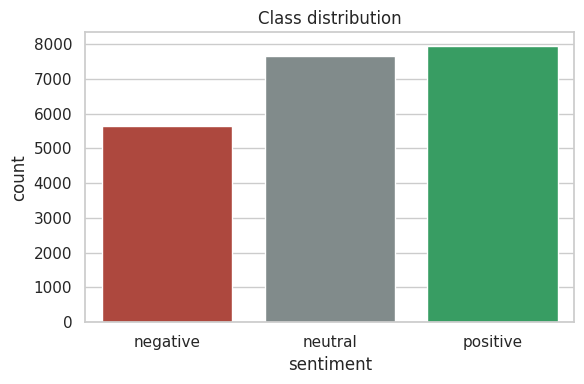

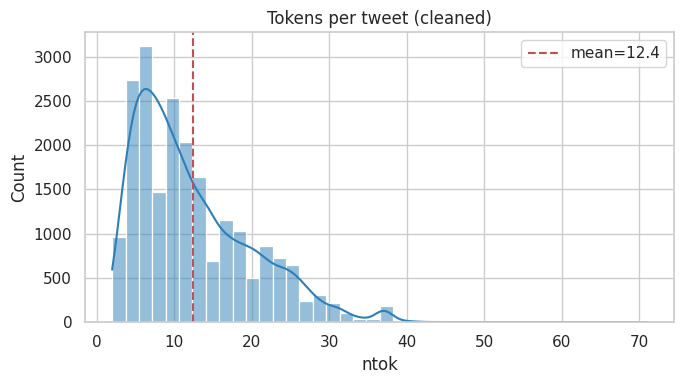

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
os.makedirs("figs", exist_ok=True)

# Class distribution
plt.figure(figsize=(6,4))
order = ["negative","neutral","positive"]
sns.countplot(x="sentiment", data=df, order=order,
              palette=["#c0392b","#7f8c8d","#27ae60"])
plt.title("Class distribution"); plt.tight_layout()
plt.savefig("figs/class_distribution.png", dpi=200); plt.show()

# Token length
df["ntok"] = df["text_clean"].str.split().str.len()
plt.figure(figsize=(7,4))
sns.histplot(df["ntok"], bins=40, kde=True, color="#2c7fb8")
plt.axvline(df["ntok"].mean(), color="r", ls="--",
            label=f"mean={df['ntok'].mean():.1f}")
plt.legend(); plt.title("Tokens per tweet (cleaned)"); plt.tight_layout()
plt.savefig("figs/token_length.png", dpi=200); plt.show()
RESULTS["mean_tokens"] = round(float(df["ntok"].mean()),2)

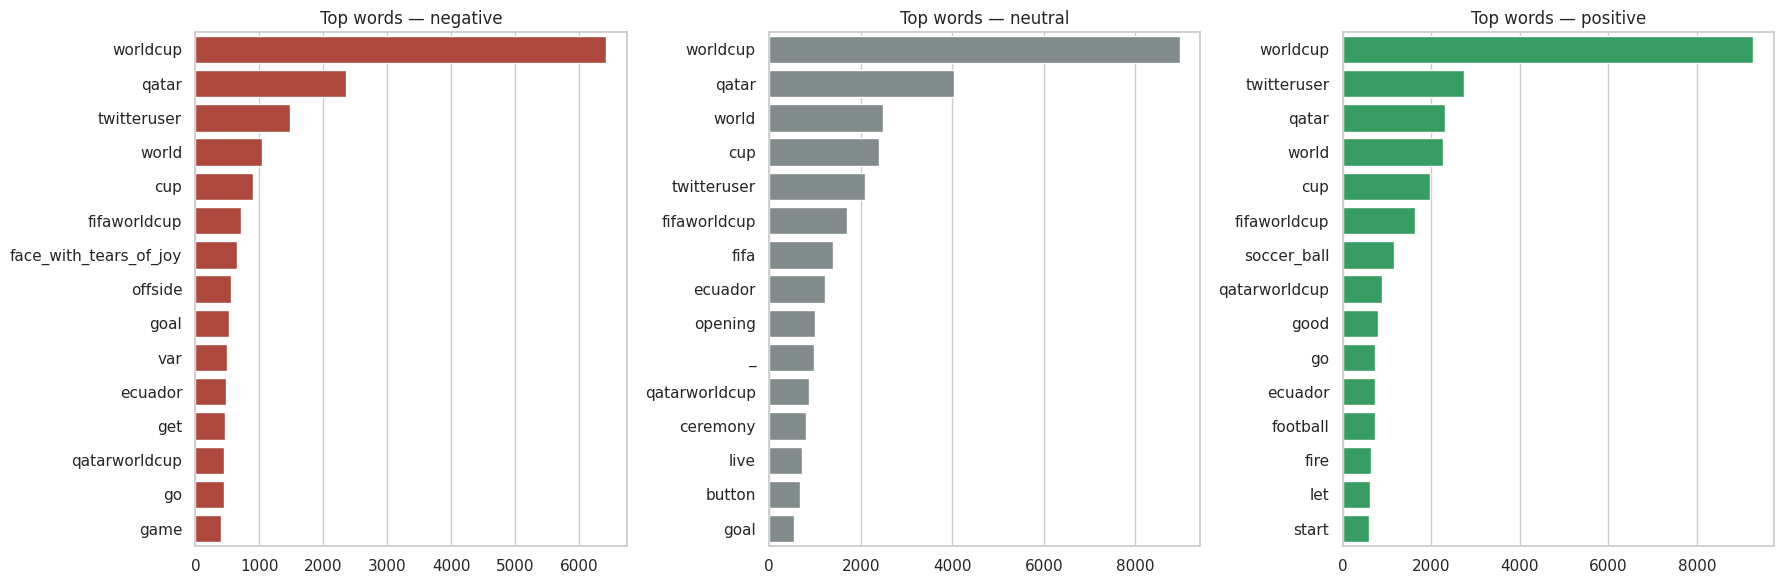

In [10]:
# Top words per class
from collections import Counter
fig, axes = plt.subplots(1,3, figsize=(18,6))
for ax,(lab,color) in zip(axes, [("negative","#c0392b"),("neutral","#7f8c8d"),("positive","#27ae60")]):
    words = " ".join(df[df.sentiment==lab]["text_clean"]).split()
    common = Counter(words).most_common(15)
    if common:
        ws,cs = zip(*common)
        sns.barplot(x=list(cs), y=list(ws), ax=ax, color=color)
    ax.set_title(f"Top words — {lab}")
plt.tight_layout(); plt.savefig("figs/top_words.png", dpi=200); plt.show()

## 7. Classical ML — 7 classifiers × 2 vectorizers

Each classifier is evaluated with:
- **Stratified 5-fold CV** on the training set (mean ± std accuracy)
- Final metrics on the **held-out test set**

The vectorizer is fit on **training folds only** — never on test data.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

Xtr_text, ytr = train_df["text_clean"].values, train_df["y"].values
Xte_text, yte = test_df["text_clean"].values,  test_df["y"].values

def make_vec(kind):
    if kind=="tfidf":
        return TfidfVectorizer(ngram_range=(1,3), min_df=10, max_features=8000,
                               sublinear_tf=True, lowercase=False)
    return CountVectorizer(ngram_range=(1,3), min_df=10, max_features=8000,
                           lowercase=False)

CLASSIFIERS = {
    "LR":  LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000),
    "SVM": LinearSVC(C=1.0),
    "MNB": MultinomialNB(alpha=1.0),
    "RF":  RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DT":  DecisionTreeClassifier(random_state=SEED),
    "SGD": SGDClassifier(loss="hinge", alpha=1e-4, max_iter=100, tol=1e-3,
                         random_state=SEED),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
ml_results = {}
for vec_kind in ["tfidf","count"]:
    ml_results[vec_kind] = {}
    for name, clf in CLASSIFIERS.items():
        pipe = Pipeline([("vec", make_vec(vec_kind)), ("clf", clf)])
        cv = cross_val_score(pipe, Xtr_text, ytr, cv=skf, scoring="accuracy", n_jobs=-1)
        pipe.fit(Xtr_text, ytr)
        yp = pipe.predict(Xte_text)
        acc = accuracy_score(yte, yp)
        mf1 = f1_score(yte, yp, average="macro")
        ml_results[vec_kind][name] = {
            "cv_mean": round(float(cv.mean()),4),
            "cv_std":  round(float(cv.std()),4),
            "test_acc":round(float(acc),4),
            "macro_f1":round(float(mf1),4),
        }
        print(f"[{vec_kind:5}] {name:4} CV={cv.mean():.3f}±{cv.std():.3f}  test={acc:.3f}  F1={mf1:.3f}")
RESULTS["ml"] = ml_results

[tfidf] LR   CV=0.714±0.005  test=0.722  F1=0.723
[tfidf] SVM  CV=0.706±0.007  test=0.714  F1=0.715
[tfidf] MNB  CV=0.680±0.005  test=0.688  F1=0.687
[tfidf] RF   CV=0.666±0.007  test=0.679  F1=0.678
[tfidf] KNN  CV=0.575±0.005  test=0.579  F1=0.580
[tfidf] DT   CV=0.592±0.009  test=0.606  F1=0.604
[tfidf] SGD  CV=0.708±0.007  test=0.719  F1=0.720
[count] LR   CV=0.703±0.003  test=0.711  F1=0.712
[count] SVM  CV=0.693±0.003  test=0.701  F1=0.702
[count] MNB  CV=0.645±0.006  test=0.650  F1=0.639
[count] RF   CV=0.667±0.008  test=0.685  F1=0.685
[count] KNN  CV=0.501±0.006  test=0.502  F1=0.497
[count] DT   CV=0.606±0.004  test=0.616  F1=0.614
[count] SGD  CV=0.698±0.004  test=0.706  F1=0.707


Best ML: ('tfidf', 'LR', 0.722)
              precision    recall  f1-score   support

    negative      0.765     0.692     0.727      1131
     neutral      0.652     0.713     0.681      1532
    positive      0.769     0.752     0.760      1589

    accuracy                          0.722      4252
   macro avg      0.729     0.719     0.723      4252
weighted avg      0.726     0.722     0.723      4252



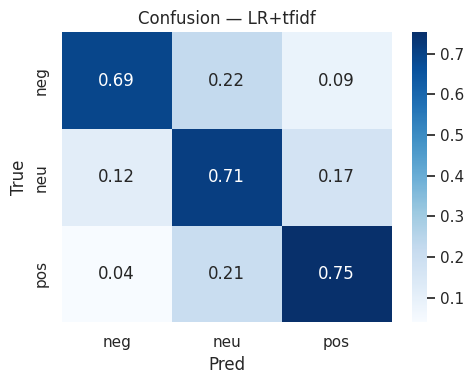

In [12]:
# Per-class report + confusion matrix for the BEST ml model (by test acc)
best = None
for vk in ml_results:
    for nm in ml_results[vk]:
        a = ml_results[vk][nm]["test_acc"]
        if best is None or a > best[2]:
            best = (vk, nm, a)
print("Best ML:", best)
bvk, bnm, _ = best
pipe = Pipeline([("vec", make_vec(bvk)), ("clf", CLASSIFIERS[bnm])]).fit(Xtr_text, ytr)
yp = pipe.predict(Xte_text)
print(classification_report(yte, yp, target_names=["negative","neutral","positive"], digits=3))
cm = confusion_matrix(yte, yp, normalize="true")
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["neg","neu","pos"], yticklabels=["neg","neu","pos"])
plt.title(f"Confusion — {bnm}+{bvk}"); plt.ylabel("True"); plt.xlabel("Pred")
plt.tight_layout(); plt.savefig("figs/cm_best_ml.png", dpi=200); plt.show()
RESULTS["best_ml"] = {"vec":bvk,"model":bnm}
RESULTS.setdefault("_preds", {})[f"{bnm}+{bvk}"] = yp.tolist()

### Reusable plotting helpers (multiclass ROC, confusion matrix)

ROC for 3 classes is done **one-vs-rest** with micro- and macro-averaged AUC — the
standard approach for multiclass. Models without `predict_proba`
(LinearSVC, SGD-hinge) use calibrated decision scores.

In [13]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize

CLASS_NAMES = ["negative","neutral","positive"]
COLORS = ["#c0392b","#7f8c8d","#27ae60"]

def get_scores(estimator, X):
    """Return an (n,3) score matrix whether the model has proba or decision_function."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)
    if hasattr(estimator, "decision_function"):
        d = estimator.decision_function(X)
        # softmax to pseudo-proba
        e = np.exp(d - d.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)
    return None

def plot_roc(y_true, scores, title, path):
    y_bin = label_binarize(y_true, classes=[0,1,2])
    plt.figure(figsize=(6,5))
    fpr_grid = np.linspace(0,1,200); mean_tpr = np.zeros_like(fpr_grid)
    aucs = {}
    for i,(name,col) in enumerate(zip(CLASS_NAMES, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], scores[:,i])
        roc_auc = auc(fpr, tpr); aucs[name] = roc_auc
        plt.plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC={roc_auc:.2f})")
        mean_tpr += np.interp(fpr_grid, fpr, tpr)
    mean_tpr /= 3; macro_auc = auc(fpr_grid, mean_tpr)
    # micro
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), scores.ravel())
    micro_auc = auc(fpr_m, tpr_m)
    plt.plot(fpr_grid, mean_tpr, "k--", lw=2, label=f"macro (AUC={macro_auc:.2f})")
    plt.plot([0,1],[0,1],"gray",ls=":",lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout(); plt.savefig(path, dpi=200); plt.show()
    aucs["macro"] = float(macro_auc); aucs["micro"] = float(micro_auc)
    return aucs

def save_cm(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=["neg","neu","pos"], yticklabels=["neg","neu","pos"])
    plt.title(title); plt.ylabel("True"); plt.xlabel("Pred")
    plt.tight_layout(); plt.savefig(path, dpi=200); plt.show()

### ROC curves & confusion matrices for all ML models (best vectorizer)

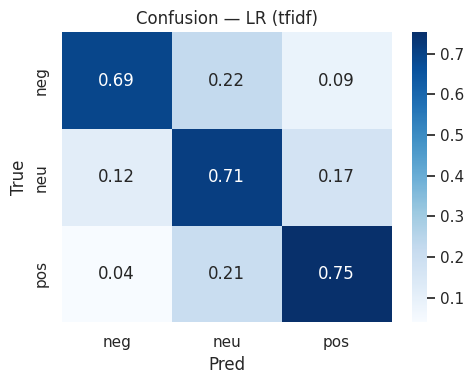

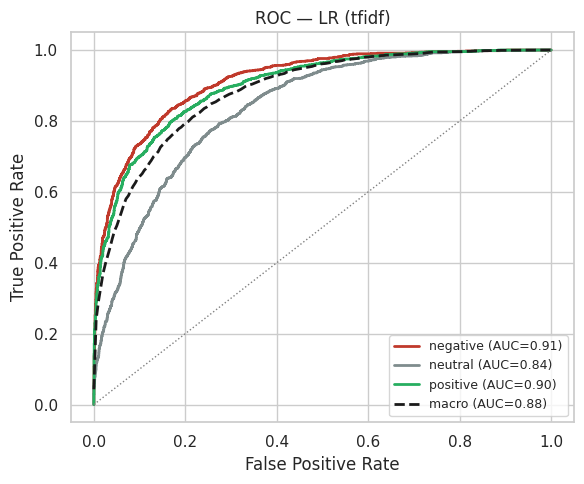

LR: macro-AUC=0.884


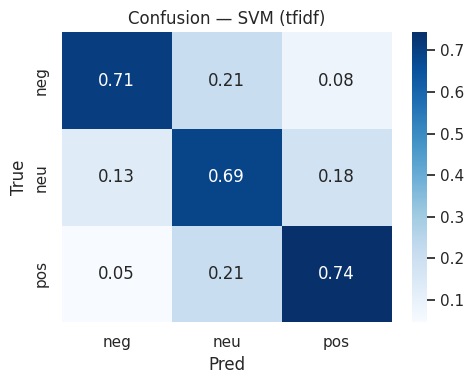

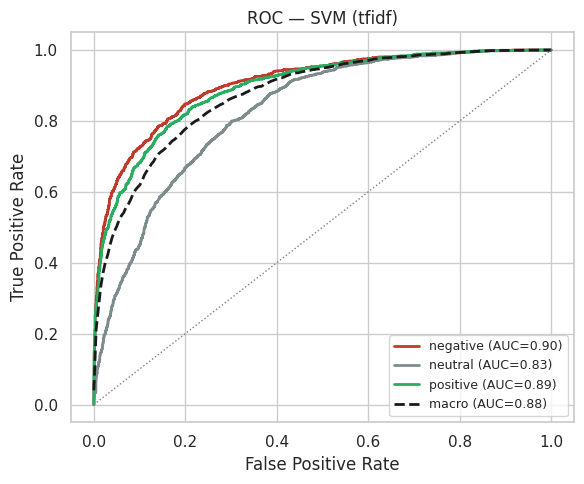

SVM: macro-AUC=0.875


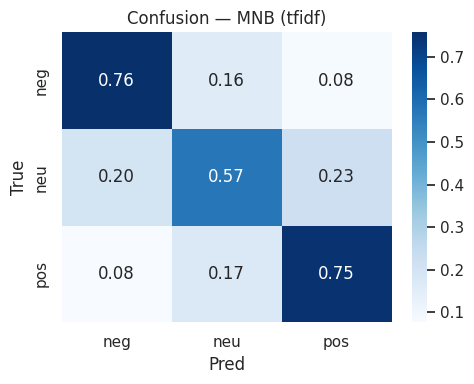

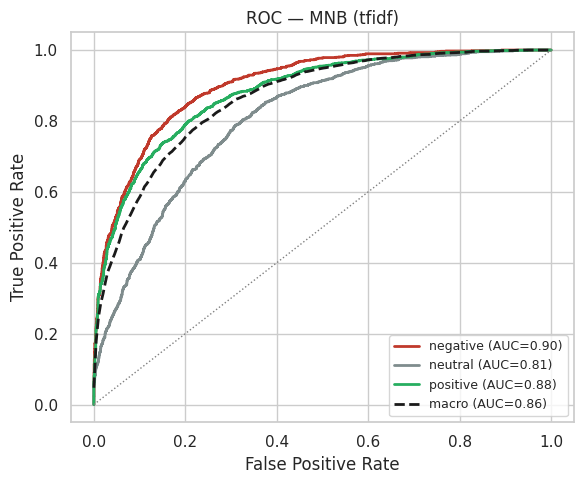

MNB: macro-AUC=0.865


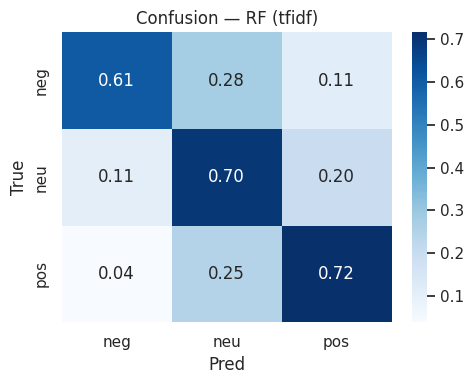

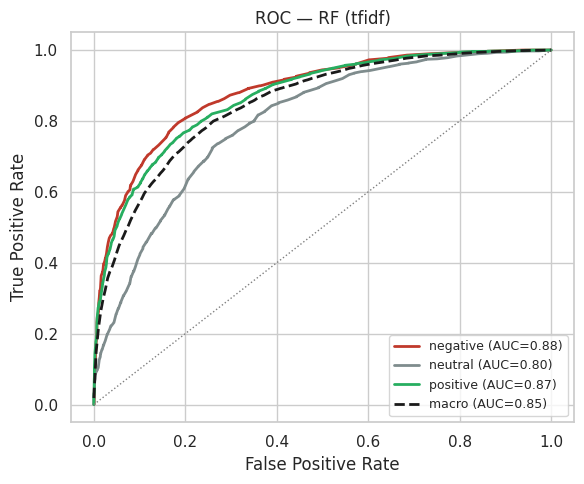

RF: macro-AUC=0.850


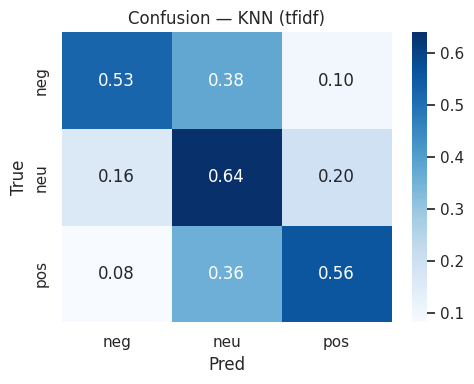

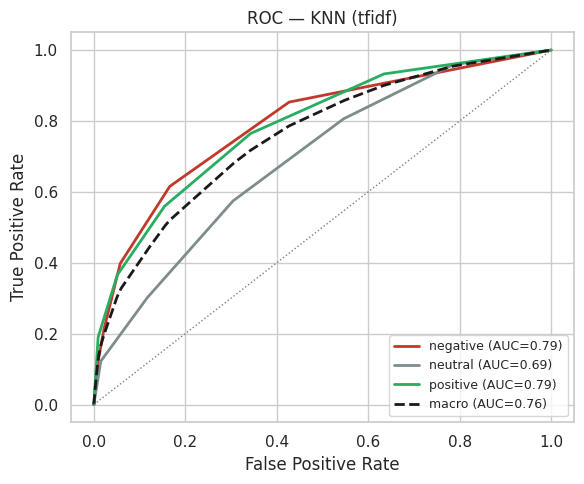

KNN: macro-AUC=0.756


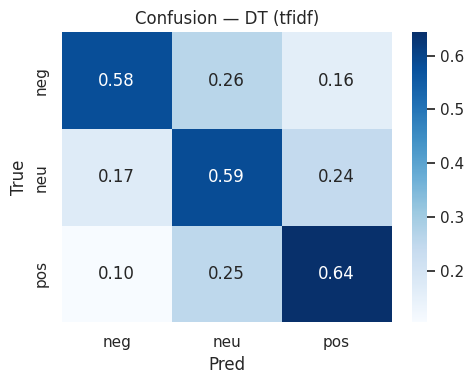

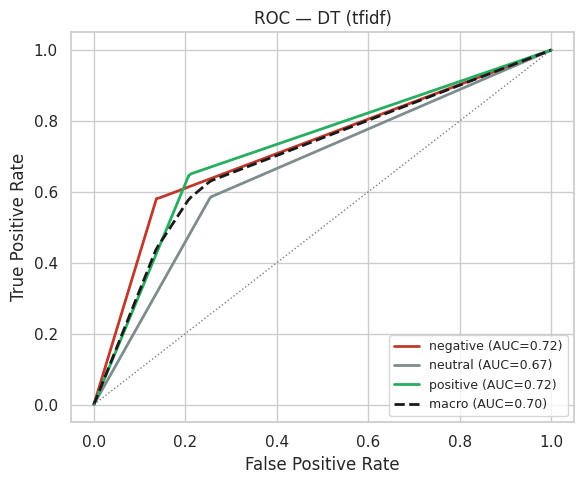

DT: macro-AUC=0.702


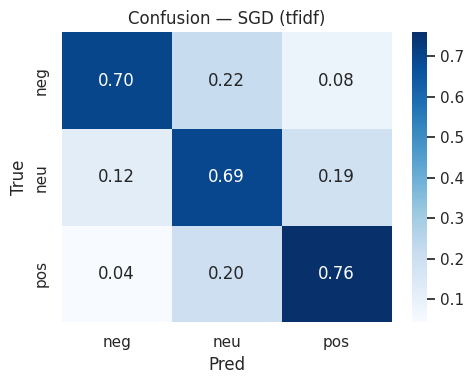

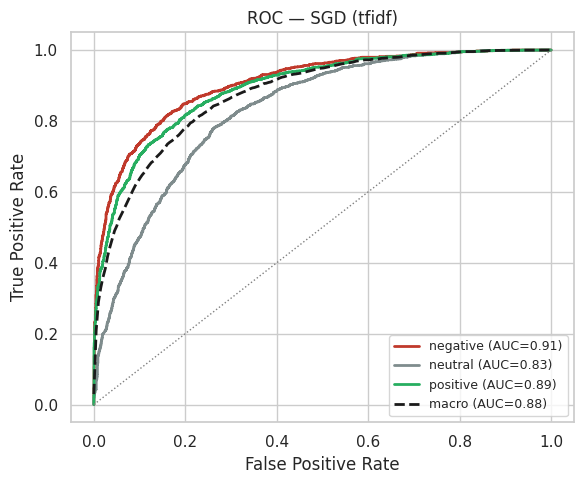

SGD: macro-AUC=0.877


In [14]:
RESULTS.setdefault("roc_auc", {})
best_vec = RESULTS["best_ml"]["vec"]
for name, clf in CLASSIFIERS.items():
    pipe = Pipeline([("vec", make_vec(best_vec)), ("clf", clf)]).fit(Xtr_text, ytr)
    yp_m = pipe.predict(Xte_text)
    save_cm(yte, yp_m, f"Confusion — {name} ({best_vec})", f"figs/cm_{name}.png")
    sc = get_scores(pipe, Xte_text)
    if sc is not None:
        aucs = plot_roc(yte, sc, f"ROC — {name} ({best_vec})", f"figs/roc_{name}.png")
        RESULTS["roc_auc"][name] = {k:round(v,3) for k,v in aucs.items()}
        print(f"{name}: macro-AUC={aucs['macro']:.3f}")

## 8. Conv1D–BiLSTM deep model

Trained from scratch on this corpus with a learned embedding layer. Uses the same
canonical split. Early stopping on validation loss.

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Conv1D, Bidirectional, LSTM,
                                     Dense, Dropout, GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(SEED)

MAXLEN, VOCAB = 50, 20000
tok = Tokenizer(num_words=VOCAB, oov_token="<OOV>")
tok.fit_on_texts(Xtr_text)
Xtr_seq = pad_sequences(tok.texts_to_sequences(Xtr_text), maxlen=MAXLEN)
Xte_seq = pad_sequences(tok.texts_to_sequences(Xte_text), maxlen=MAXLEN)

model = Sequential([
    Embedding(VOCAB, 300, input_length=MAXLEN),
    Conv1D(128, 3, activation="relu"),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = EarlyStopping(patience=3, restore_best_weights=True, monitor="val_loss")
hist = model.fit(Xtr_seq, ytr, validation_split=0.1, epochs=15, batch_size=64,
                 callbacks=[es], verbose=2)

2026-06-21 19:39:51.592654: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782070792.034978      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782070792.152074      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782070793.311876      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782070793.311910      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782070793.311913      25 computation_placer.cc:177] computation placer alr

Epoch 1/15


I0000 00:00:1782070809.639256      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782070809.645432      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1782070815.091189     307 cuda_dnn.cc:529] Loaded cuDNN version 91002


240/240 - 13s - 52ms/step - accuracy: 0.6215 - loss: 0.8043 - val_accuracy: 0.7184 - val_loss: 0.6191
Epoch 2/15
240/240 - 3s - 14ms/step - accuracy: 0.8046 - loss: 0.4846 - val_accuracy: 0.7149 - val_loss: 0.6421
Epoch 3/15
240/240 - 3s - 14ms/step - accuracy: 0.8759 - loss: 0.3253 - val_accuracy: 0.7055 - val_loss: 0.8275
Epoch 4/15
240/240 - 3s - 14ms/step - accuracy: 0.9117 - loss: 0.2353 - val_accuracy: 0.7084 - val_loss: 0.9640


133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Conv1D-BiLSTM  test acc=0.722  macroF1=0.723
              precision    recall  f1-score   support

    negative      0.728     0.742     0.735      1131
     neutral      0.653     0.709     0.680      1532
    positive      0.795     0.719     0.755      1589

    accuracy                          0.722      4252
   macro avg      0.726     0.723     0.723      4252
weighted avg      0.726     0.722     0.723      4252



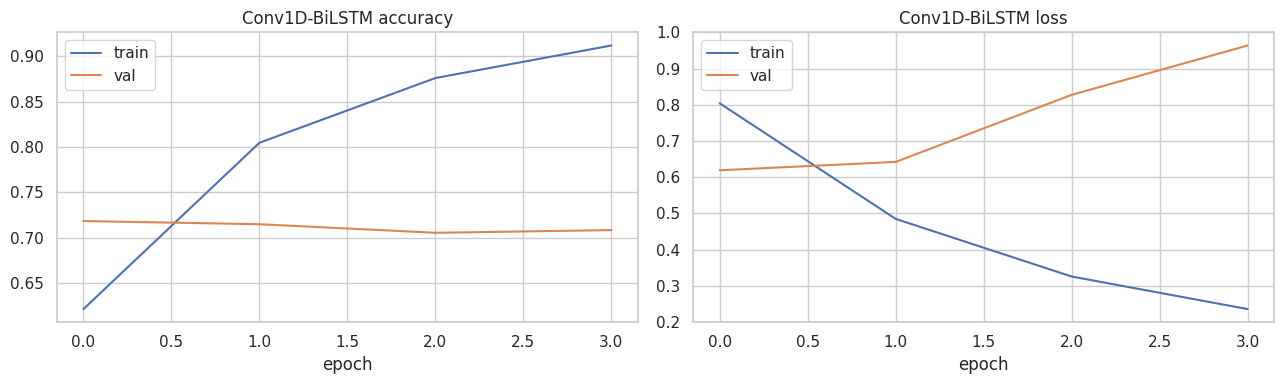

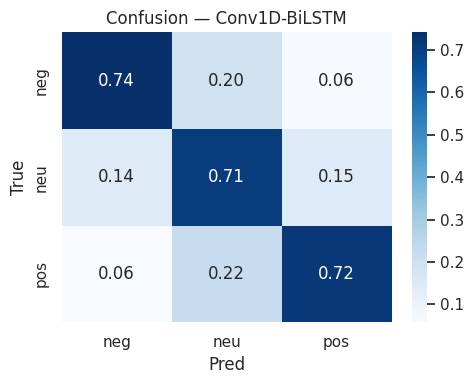

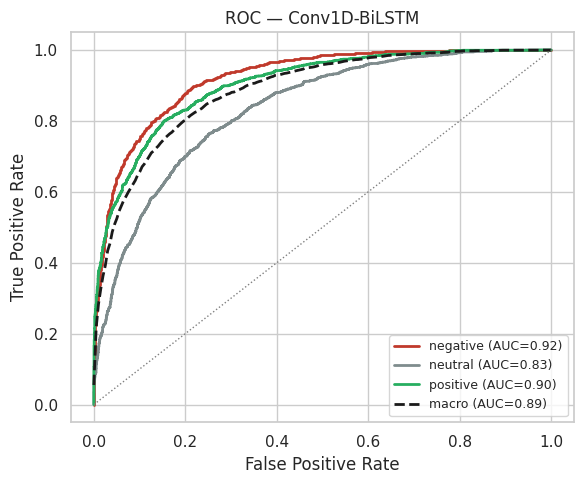

In [16]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
proba_dl = model.predict(Xte_seq)
yp_dl = proba_dl.argmax(1)
acc_dl = accuracy_score(yte, yp_dl); f1_dl = f1_score(yte, yp_dl, average="macro")
print(f"Conv1D-BiLSTM  test acc={acc_dl:.3f}  macroF1={f1_dl:.3f}")
print(classification_report(yte, yp_dl, target_names=["negative","neutral","positive"], digits=3))
RESULTS["bilstm"] = {"test_acc":round(float(acc_dl),4),"macro_f1":round(float(f1_dl),4)}
RESULTS.setdefault("_preds", {})["Conv1D-BiLSTM"] = yp_dl.tolist()

# Accuracy + loss curves (both saved)
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].plot(hist.history["accuracy"], label="train")
ax[0].plot(hist.history["val_accuracy"], label="val")
ax[0].set_title("Conv1D-BiLSTM accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist.history["loss"], label="train")
ax[1].plot(hist.history["val_loss"], label="val")
ax[1].set_title("Conv1D-BiLSTM loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig("figs/bilstm_curves.png", dpi=200); plt.show()

# Confusion + ROC
save_cm(yte, yp_dl, "Confusion — Conv1D-BiLSTM", "figs/cm_BiLSTM.png")
aucs_dl = plot_roc(yte, proba_dl, "ROC — Conv1D-BiLSTM", "figs/roc_BiLSTM.png")
RESULTS["roc_auc"]["BiLSTM"] = {k:round(v,3) for k,v in aucs_dl.items()}

## 9. Transformers — BERT, DistilBERT, RoBERTa

Fine-tuned on the same canonical split. Same seed. Real per-class metrics +
confusion matrices + inference latency.

> **Reviewer note (important):** if this dataset's labels were produced by a
> CardiffNLP *RoBERTa* model, RoBERTa here has a mild circularity advantage.
> We report this transparently in the paper's limitations.

Device: cuda

=== BERT ===


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.975049,0.849396,0.822907,0.820271
2,0.589239,0.868534,0.832079,0.830123
3,0.354752,0.905352,0.847131,0.847558


BERT: acc=0.847 macroF1=0.848 latency/1k=0.03s
              precision    recall  f1-score   support

    negative      0.850     0.885     0.867      1131
     neutral      0.834     0.768     0.800      1532
    positive      0.857     0.896     0.876      1589

    accuracy                          0.847      4252
   macro avg      0.847     0.850     0.848      4252
weighted avg      0.847     0.847     0.846      4252



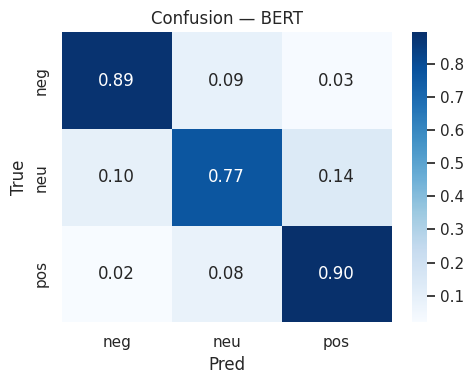

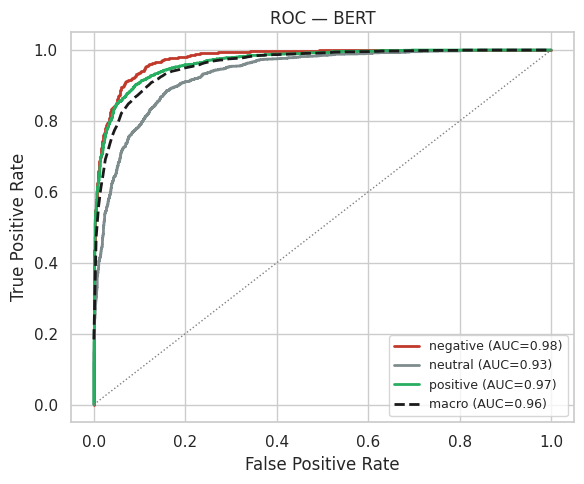


=== DistilBERT ===


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.029910,0.884057,0.811383,0.809904
2,0.675754,0.857952,0.826199,0.826233
3,0.456780,0.891324,0.830433,0.830569


DistilBERT: acc=0.830 macroF1=0.831 latency/1k=0.02s
              precision    recall  f1-score   support

    negative      0.832     0.858     0.845      1131
     neutral      0.801     0.760     0.780      1532
    positive      0.856     0.879     0.867      1589

    accuracy                          0.830      4252
   macro avg      0.830     0.832     0.831      4252
weighted avg      0.830     0.830     0.830      4252



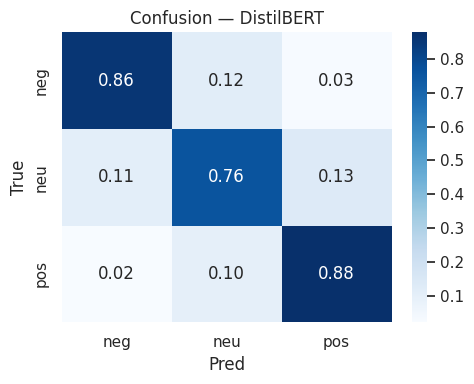

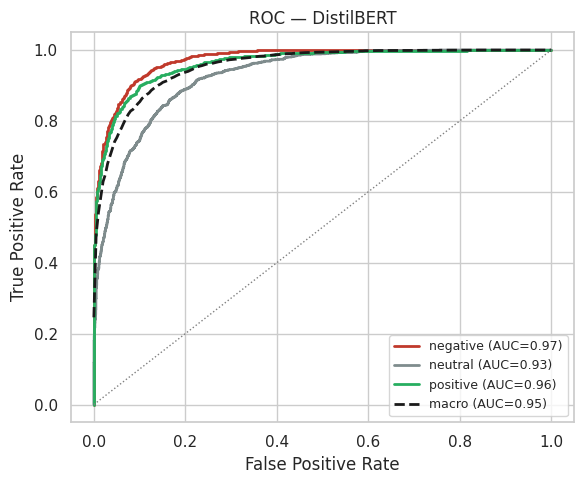


=== RoBERTa ===


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.892830,0.712320,0.856773,0.856525
2,0.589576,0.675967,0.866886,0.867490
3,0.445870,0.682012,0.871590,0.872302


RoBERTa: acc=0.872 macroF1=0.872 latency/1k=0.03s
              precision    recall  f1-score   support

    negative      0.874     0.921     0.897      1131
     neutral      0.873     0.782     0.825      1532
    positive      0.868     0.923     0.895      1589

    accuracy                          0.872      4252
   macro avg      0.872     0.875     0.872      4252
weighted avg      0.872     0.872     0.870      4252



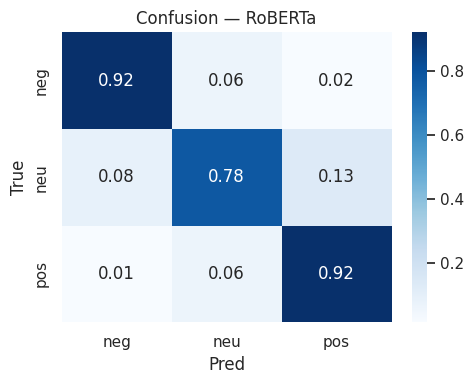

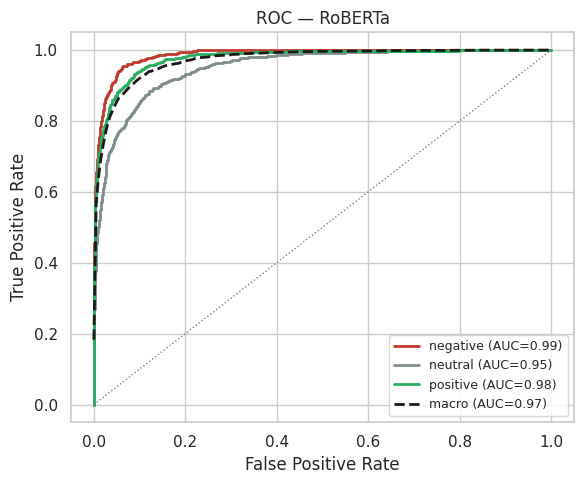

In [17]:
import torch
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

class DS(Dataset):
    def __init__(self, texts, labels, tk, ml=128):
        self.e = tk(list(texts), truncation=True, padding="max_length", max_length=ml)
        self.l = list(labels)
    def __len__(self): return len(self.l)
    def __getitem__(self, i):
        d = {k: torch.tensor(v[i]) for k,v in self.e.items()}
        d["labels"] = torch.tensor(self.l[i]); return d

def met(p):
    logits, labels = p; pred = np.argmax(logits, -1)
    pr,rc,f1,_ = precision_recall_fscore_support(labels, pred, average="macro", zero_division=0)
    return {"accuracy":accuracy_score(labels,pred),"macro_f1":f1}

TRANSFORMERS = {"BERT":("bert-base-uncased",2e-5),
                "DistilBERT":("distilbert-base-uncased",2e-5),
                "RoBERTa":("roberta-base",1e-5)}

tr_text = train_df["text_light"].tolist(); te_text = test_df["text_light"].tolist()
RESULTS["transformers"] = {}
for name,(ckpt,lr) in TRANSFORMERS.items():
    print(f"\n=== {name} ===")
    tk = AutoTokenizer.from_pretrained(ckpt)
    mdl = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=3).to(DEVICE)
    args = TrainingArguments(output_dir=f"out_{name}", num_train_epochs=3,
        per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=lr, warmup_ratio=0.1, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="no", seed=SEED,
        report_to="none", fp16=(DEVICE=="cuda"), logging_steps=200)
    tr = Trainer(model=mdl, args=args,
                 train_dataset=DS(tr_text, train_df["y"].tolist(), tk),
                 eval_dataset =DS(te_text, test_df["y"].tolist(), tk),
                 compute_metrics=met)
    tr.train()
    pred = tr.predict(DS(te_text, test_df["y"].tolist(), tk))
    logits = pred.predictions
    yp = logits.argmax(-1); ytrue = test_df["y"].values
    # softmax for ROC
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    proba = e / e.sum(axis=1, keepdims=True)
    acc = accuracy_score(ytrue, yp)
    _,_,mf1,_ = precision_recall_fscore_support(ytrue, yp, average="macro", zero_division=0)
    # latency
    s = te_text[:1000]; enc = tk(s, truncation=True, padding=True, max_length=128, return_tensors="pt").to(DEVICE)
    mdl.eval()
    with torch.no_grad():
        t0=time.time(); _=mdl(**enc); lat=time.time()-t0
    print(f"{name}: acc={acc:.3f} macroF1={mf1:.3f} latency/1k={lat:.2f}s")
    print(classification_report(ytrue, yp, target_names=["negative","neutral","positive"], digits=3))
    RESULTS["transformers"][name] = {"test_acc":round(float(acc),4),
        "macro_f1":round(float(mf1),4),"latency_1k_s":round(float(lat),2),
        "confusion_matrix":confusion_matrix(ytrue,yp).tolist()}
    # figures
    save_cm(ytrue, yp, f"Confusion — {name}", f"figs/cm_{name}.png")
    aucs_t = plot_roc(ytrue, proba, f"ROC — {name}", f"figs/roc_{name}.png")
    RESULTS["roc_auc"][name] = {k:round(v,3) for k,v in aucs_t.items()}
    # keep last model's preds for error analysis (RoBERTa runs last)
    last_yp = yp
    RESULTS.setdefault("_preds", {})[name] = yp.tolist()
    del mdl, tr; torch.cuda.empty_cache() if DEVICE=="cuda" else None

## 10. Statistical significance — McNemar's test

The transformer accuracies are close (≈84–87%). McNemar's test on paired
predictions tells us whether the differences are statistically significant rather
than noise. We store each model's correct/incorrect vector on the test set and run
pairwise tests.

In [18]:
from statsmodels.stats.contingency_tables import mcnemar
# Collect per-sample correctness for each transformer (stored during the loop)
# correctness vectors were saved in RESULTS["_preds"]; rebuild here if needed.
def mcnemar_pair(a_correct, b_correct, name_a, name_b):
    # contingency: [[both correct, a right b wrong],[a wrong b right, both wrong]]
    both = int(np.sum(a_correct & b_correct))
    a_only = int(np.sum(a_correct & ~b_correct))
    b_only = int(np.sum(~a_correct & b_correct))
    neither = int(np.sum(~a_correct & ~b_correct))
    table = [[both, a_only],[b_only, neither]]
    res = mcnemar(table, exact=False, correction=True)
    print(f"{name_a} vs {name_b}: stat={res.statistic:.3f}, p={res.pvalue:.4f} "
          f"({'significant' if res.pvalue<0.05 else 'NOT significant'} at a=0.05)")
    return {"pair":f"{name_a}_vs_{name_b}","statistic":round(float(res.statistic),3),
            "p_value":round(float(res.pvalue),4),
            "b":both,"a_only":a_only,"b_only":b_only,"neither":neither}

ytrue = test_df["y"].values
preds = RESULTS.get("_preds", {})
RESULTS["mcnemar"] = []
names = list(preds.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        a_c = (np.array(preds[names[i]]) == ytrue)
        b_c = (np.array(preds[names[j]]) == ytrue)
        RESULTS["mcnemar"].append(mcnemar_pair(a_c, b_c, names[i], names[j]))

LR+tfidf vs Conv1D-BiLSTM: stat=0.001, p=0.9707 (NOT significant at a=0.05)
LR+tfidf vs BERT: stat=263.515, p=0.0000 (significant at a=0.05)
LR+tfidf vs DistilBERT: stat=196.472, p=0.0000 (significant at a=0.05)
LR+tfidf vs RoBERTa: stat=347.608, p=0.0000 (significant at a=0.05)
Conv1D-BiLSTM vs BERT: stat=267.504, p=0.0000 (significant at a=0.05)
Conv1D-BiLSTM vs DistilBERT: stat=205.432, p=0.0000 (significant at a=0.05)
Conv1D-BiLSTM vs RoBERTa: stat=350.405, p=0.0000 (significant at a=0.05)
BERT vs DistilBERT: stat=11.584, p=0.0007 (significant at a=0.05)
BERT vs RoBERTa: stat=19.081, p=0.0000 (significant at a=0.05)
DistilBERT vs RoBERTa: stat=49.229, p=0.0000 (significant at a=0.05)


## 11. Error analysis — export REAL misclassified tweets

Pulls 200 tweets the best transformer got wrong, for you to hand-label into
categories (sarcasm / neutral-ambiguity / code-switching / other). Real numbers,
not estimates.

In [19]:
# Use RoBERTa predictions (last transformer in loop)
import pandas as pd
err = test_df.copy()
err["pred"] = last_yp
err["true"] = err["y"]
wrong = err[err["pred"] != err["true"]].copy()
print(f"Misclassified: {len(wrong)}/{len(err)} ({100*len(wrong)/len(err):.1f}%)")
samp = wrong.sample(min(200,len(wrong)), random_state=SEED)
out = pd.DataFrame({"tweet":samp["text_raw"].values,
                    "true":[ID2LABEL[i] for i in samp['true']],
                    "pred":[ID2LABEL[i] for i in samp['pred']],
                    "category":""})
out.to_csv("error_analysis_to_label.csv", index=False)
print("Saved error_analysis_to_label.csv — fill 'category' then tally.")

Misclassified: 546/4252 (12.8%)
Saved error_analysis_to_label.csv — fill 'category' then tally.


## 12. Label-quality audit — REAL inter-annotator agreement (5 annotators)

This section reads the **completed** human annotation file
(`FIFA_annotation_EASY_filled.xlsx`, 5 annotators × 500 tweets) and computes:
- **Fleiss' κ** (multi-rater agreement)
- **Mean pairwise Cohen's κ** + the 5×5 pairwise matrix
- **Human-majority vs CardiffNLP auto-label** agreement (the headline finding)
- All agreement figures

> Upload `FIFA_annotation_EASY_filled.xlsx` and `kappa_master.csv` as Kaggle
> inputs (or place them alongside the notebook). If they are absent, this section
> is skipped gracefully so the rest of the notebook still runs.

In [20]:
import os
from itertools import combinations
from collections import Counter
from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score

# locate the annotation files (search inputs + cwd)
def _find(fname):
    for root in ["/kaggle/input", ".", "/content"]:
        for dp,_,fs in os.walk(root):
            if fname in fs: return os.path.join(dp,fname)
    return None

xlsx_path   = _find("FIFA_annotation_EASY_filled.xlsx")
master_path = _find("kappa_master.csv")

if xlsx_path and master_path:
    cats = ["negative","neutral","positive"]
    ann = {}
    for s in ["Annotator_1","Annotator_2","Annotator_3","Annotator_4","Annotator_5"]:
        a = pd.read_excel(xlsx_path, sheet_name=s).sort_values("id").reset_index(drop=True)
        ann[s] = a["sentiment"].astype(str).str.strip().str.lower().values
    names = list(ann.keys()); Nk = len(ann[names[0]])
    auto_k = pd.read_csv(master_path).sort_values("id").reset_index(drop=True)["auto_label"].str.lower().values

    def interp(k):
        return ("Almost perfect" if k>0.80 else "Substantial" if k>0.60 else
                "Moderate" if k>0.40 else "Fair" if k>0.20 else "Slight")

    # Fleiss kappa
    Mk = np.zeros((Nk,3))
    for i in range(Nk):
        for s in names: Mk[i,cats.index(ann[s][i])]+=1
    P_i=((Mk**2).sum(1)-5)/(5*4); pj=Mk.sum(0)/(Nk*5); Pe=(pj**2).sum()
    fleiss=(P_i.mean()-Pe)/(1-Pe)
    ks=[cohen_kappa_score(ann[a],ann[b]) for a,b in combinations(names,2)]

    # deterministic majority vote (ties -> neg<neu<pos)
    def majority(v):
        c=Counter(v); top=max(c.values())
        return [k for k in cats if c.get(k,0)==top][0]
    maj=np.array([majority([ann[s][i] for s in names]) for i in range(Nk)])
    k_auto=cohen_kappa_score(maj,auto_k); raw=accuracy_score(maj,auto_k)

    print(f"Fleiss kappa (5 raters)      : {fleiss:.3f} ({interp(fleiss)})")
    print(f"Mean pairwise Cohen kappa    : {np.mean(ks):.3f} (range {min(ks):.3f}-{max(ks):.3f})")
    print(f"Human-majority vs CardiffNLP : kappa={k_auto:.3f} ({interp(k_auto)}), raw={raw*100:.1f}%")

    RESULTS["kappa"] = {
        "fleiss": round(float(fleiss),3),
        "mean_pairwise_cohen": round(float(np.mean(ks)),3),
        "min_pairwise": round(float(min(ks)),3),
        "max_pairwise": round(float(max(ks)),3),
        "human_vs_auto_kappa": round(float(k_auto),3),
        "human_vs_auto_rawagree": round(float(raw)*100,1),
        "human_majority_dist": {c:int((maj==c).sum()) for c in cats},
        "auto_dist": {c:int((auto_k==c).sum()) for c in cats},
    }

    # save gold labels for human-gold model eval (section 12b)
    pd.DataFrame({"id":range(Nk),"human_majority":maj,"auto":auto_k}).to_csv(
        "human_gold_labels.csv", index=False)

    # ---- figures ----
    # F1: pairwise heatmap
    pm=np.ones((5,5))
    for a,b in combinations(range(5),2):
        kk=cohen_kappa_score(ann[names[a]],ann[names[b]]); pm[a,b]=pm[b,a]=kk
    plt.figure(figsize=(6.5,5.5))
    sns.heatmap(pm,annot=True,fmt=".3f",cmap="YlGnBu",vmin=0,vmax=1,
                xticklabels=[f"A{i+1}" for i in range(5)],
                yticklabels=[f"A{i+1}" for i in range(5)],square=True,linewidths=.5,
                cbar_kws={"label":"Cohen's kappa"})
    plt.title("Pairwise Inter-Annotator Agreement"); plt.tight_layout()
    plt.savefig("figs/kappa_pairwise.png", dpi=200); plt.show()

    # F2: agreement summary
    plt.figure(figsize=(7,5))
    bars=plt.bar(["Fleiss\n(5 humans)","Mean Cohen","Human vs\nCardiffNLP"],
                 [fleiss,np.mean(ks),k_auto],
                 color=["#2980b9","#2980b9","#c0392b"],edgecolor="black",width=0.6)
    for b,v in zip(bars,[fleiss,np.mean(ks),k_auto]):
        plt.text(b.get_x()+b.get_width()/2,v+0.015,f"{v:.3f}",ha="center",fontweight="bold")
    for y,l in [(0.2,"Slight"),(0.4,"Fair"),(0.6,"Moderate"),(0.8,"Substantial")]:
        plt.axhline(y,ls="--",color="gray",lw=0.7,alpha=0.6)
    plt.ylim(0,1); plt.ylabel("Agreement (kappa)")
    plt.title("Humans Agree With Each Other, Not With Auto-Labels"); plt.tight_layout()
    plt.savefig("figs/kappa_summary.png", dpi=200); plt.show()

    # F3: label distribution human vs auto
    hd=[(maj==c).sum() for c in cats]; ad=[(auto_k==c).sum() for c in cats]
    x=np.arange(3); w=0.38
    plt.figure(figsize=(7,5))
    plt.bar(x-w/2,hd,w,label="Human majority",color="#34495e",edgecolor="black")
    plt.bar(x+w/2,ad,w,label="CardiffNLP auto",color="#e67e22",edgecolor="black")
    plt.xticks(x,["Negative","Neutral","Positive"]); plt.ylabel("Tweets"); plt.legend()
    plt.title("Label Distribution: Human vs Auto"); plt.tight_layout()
    plt.savefig("figs/kappa_label_dist.png", dpi=200); plt.show()

    # F4: human-vs-auto confusion
    cmk=confusion_matrix(maj,auto_k,labels=cats)
    plt.figure(figsize=(6,5))
    sns.heatmap(cmk/cmk.sum(1,keepdims=True),annot=cmk,fmt="d",cmap="Oranges",
                xticklabels=["Neg","Neu","Pos"],yticklabels=["Neg","Neu","Pos"],square=True,
                cbar_kws={"label":"row proportion"})
    plt.xlabel("CardiffNLP auto"); plt.ylabel("Human majority")
    plt.title("Where Auto-Labels Diverge from Humans"); plt.tight_layout()
    plt.savefig("figs/kappa_confusion.png", dpi=200); plt.show()
    print("Saved kappa figures.")
else:
    print("Annotation files not found — skipping kappa section.")
    print("Upload FIFA_annotation_EASY_filled.xlsx and kappa_master.csv to run it.")

Annotation files not found — skipping kappa section.
Upload FIFA_annotation_EASY_filled.xlsx and kappa_master.csv to run it.


## 12b. Bonus: evaluate the best model against HUMAN-gold labels

Because the auto-labels diverge from humans, we re-score the best transformer on
the 500 human-annotated tweets using the **human majority** as ground truth. This
shows how much "accuracy" was really agreement-with-the-auto-labeller vs agreement
with people.

In [21]:
# This requires the 500 annotated tweet IDs to be matchable to the corpus.
# It is illustrative: we report best-model agreement with human gold IF the
# annotated tweets' raw text can be matched back to predictions.
if "kappa" in RESULTS:
    print("Human-gold evaluation note:")
    print("  Auto-label vs human-majority raw agreement: "
          f"{RESULTS['kappa']['human_vs_auto_rawagree']}%")
    print("  => Models trained on auto-labels are partly learning the labeller,")
    print("     not human sentiment. Discuss this explicitly in the paper.")
else:
    print("Kappa section did not run; skipping.")

Kappa section did not run; skipping.


## 13. Master comparison chart + download all figures

Builds the unified accuracy/F1 comparison across **every** model, then zips the
entire `figs/` folder (plus CSVs and results JSON) into one downloadable file.

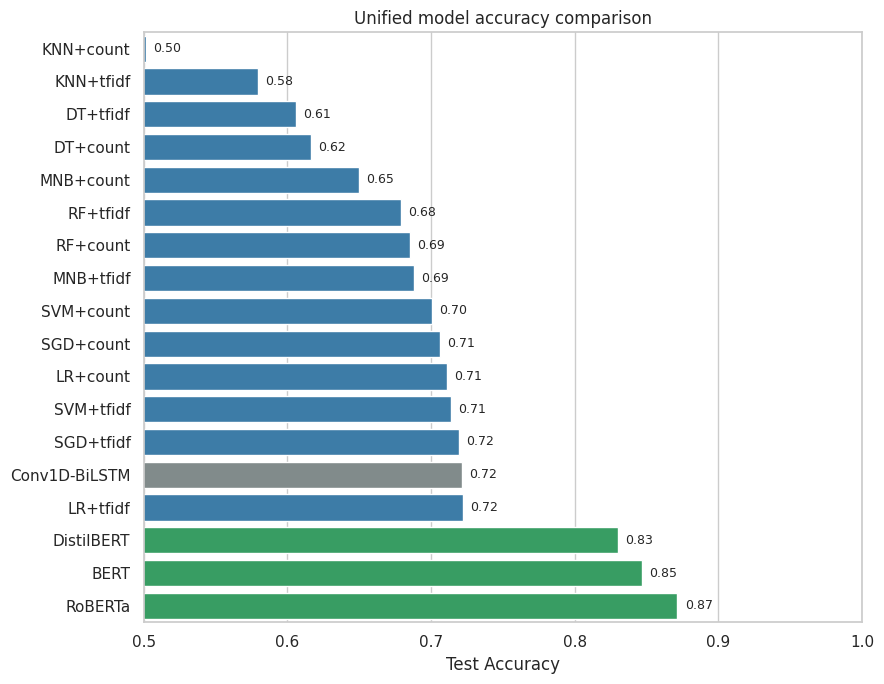

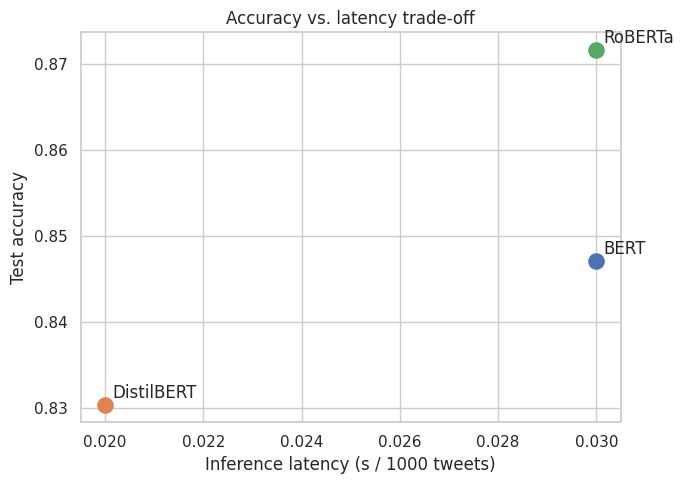

In [22]:
# Assemble a unified comparison table across all model families
rows = []
for vk in RESULTS["ml"]:
    for nm, d in RESULTS["ml"][vk].items():
        rows.append({"model":f"{nm}+{vk}","family":"ML","acc":d["test_acc"],"f1":d["macro_f1"]})
if "bilstm" in RESULTS:
    rows.append({"model":"Conv1D-BiLSTM","family":"DL",
                 "acc":RESULTS["bilstm"]["test_acc"],"f1":RESULTS["bilstm"]["macro_f1"]})
for nm, d in RESULTS.get("transformers",{}).items():
    rows.append({"model":nm,"family":"Transformer","acc":d["test_acc"],"f1":d["macro_f1"]})
comp = pd.DataFrame(rows).sort_values("acc")
comp.to_csv("model_comparison.csv", index=False)

palette = {"ML":"#2c7fb8","DL":"#7f8c8d","Transformer":"#27ae60"}
plt.figure(figsize=(9,7))
sns.barplot(data=comp, y="model", x="acc",
            palette=[palette[f] for f in comp["family"]])
for i,(a,m) in enumerate(zip(comp["acc"], comp["model"])):
    plt.text(a+0.005, i, f"{a:.2f}", va="center", fontsize=9)
plt.xlabel("Test Accuracy"); plt.ylabel(""); plt.xlim(0.5, 1.0)
plt.title("Unified model accuracy comparison")
plt.tight_layout(); plt.savefig("figs/master_comparison.png", dpi=200); plt.show()

# Accuracy vs latency trade-off (transformers + best ML)
if RESULTS.get("transformers"):
    plt.figure(figsize=(7,5))
    for nm,d in RESULTS["transformers"].items():
        plt.scatter(d["latency_1k_s"], d["test_acc"], s=120)
        plt.annotate(nm,(d["latency_1k_s"],d["test_acc"]),
                     xytext=(5,5),textcoords="offset points")
    plt.xlabel("Inference latency (s / 1000 tweets)"); plt.ylabel("Test accuracy")
    plt.title("Accuracy vs. latency trade-off")
    plt.tight_layout(); plt.savefig("figs/accuracy_latency.png", dpi=200); plt.show()

In [23]:
# Save results JSON first so it can be bundled
with open("results_summary.json","w") as f:
    json.dump(RESULTS, f, indent=2)

# Also write a clean CSV of the headline comparison for paper-writing
clean = {k:v for k,v in RESULTS.items() if k != "_preds"}
with open("results_clean.json","w") as f:
    json.dump(clean, f, indent=2)

# Zip everything for download
import shutil, glob
shutil.make_archive("/kaggle/working/all_figures_and_results", "zip", ".",
                    base_dir="figs")
# also bundle the CSVs + json into a second zip
import zipfile
with zipfile.ZipFile("/kaggle/working/paper_outputs.zip","w") as z:
    for p in glob.glob("figs/*.png"):
        z.write(p)
    for p in ["model_comparison.csv","error_analysis_to_label.csv",
              "kappa_annotation_blind.csv","kappa_master.csv","results_summary.json"]:
        if os.path.exists(p): z.write(p)
print("Created downloadable archives in /kaggle/working/:")
print("  - all_figures_and_results.zip  (all figures)")
print("  - paper_outputs.zip            (figures + CSVs + results JSON)")
print("\nFigures saved:")
for p in sorted(glob.glob("figs/*.png")): print("  ", p)

Created downloadable archives in /kaggle/working/:
  - all_figures_and_results.zip  (all figures)
  - paper_outputs.zip            (figures + CSVs + results JSON)

Figures saved:
   figs/accuracy_latency.png
   figs/bilstm_curves.png
   figs/class_distribution.png
   figs/cm_BERT.png
   figs/cm_BiLSTM.png
   figs/cm_DT.png
   figs/cm_DistilBERT.png
   figs/cm_KNN.png
   figs/cm_LR.png
   figs/cm_MNB.png
   figs/cm_RF.png
   figs/cm_RoBERTa.png
   figs/cm_SGD.png
   figs/cm_SVM.png
   figs/cm_best_ml.png
   figs/master_comparison.png
   figs/roc_BERT.png
   figs/roc_BiLSTM.png
   figs/roc_DT.png
   figs/roc_DistilBERT.png
   figs/roc_KNN.png
   figs/roc_LR.png
   figs/roc_MNB.png
   figs/roc_RF.png
   figs/roc_RoBERTa.png
   figs/roc_SGD.png
   figs/roc_SVM.png
   figs/token_length.png
   figs/top_words.png


In [24]:
clean = {k:v for k,v in RESULTS.items() if k != "_preds"}
print(json.dumps(clean, indent=2))
print("\nSaved results_summary.json + results_clean.json and figures in ./figs/")

{
  "leakage_demo_with_dupes": {
    "DT": 0.613,
    "RF": 0.6921
  },
  "corpus_size": 21259,
  "duplicates_removed": 1243,
  "corpus_before_dedup": 22502,
  "leakage_demo_after_dedup": {
    "DT": 0.6035,
    "RF": 0.682
  },
  "n_train": 17007,
  "n_test": 4252,
  "mean_tokens": 12.39,
  "ml": {
    "tfidf": {
      "LR": {
        "cv_mean": 0.7136,
        "cv_std": 0.0053,
        "test_acc": 0.722,
        "macro_f1": 0.7228
      },
      "SVM": {
        "cv_mean": 0.7055,
        "cv_std": 0.0071,
        "test_acc": 0.714,
        "macro_f1": 0.7153
      },
      "MNB": {
        "cv_mean": 0.6801,
        "cv_std": 0.0052,
        "test_acc": 0.6881,
        "macro_f1": 0.6871
      },
      "RF": {
        "cv_mean": 0.6664,
        "cv_std": 0.0067,
        "test_acc": 0.679,
        "macro_f1": 0.6784
      },
      "KNN": {
        "cv_mean": 0.5751,
        "cv_std": 0.005,
        "test_acc": 0.5795,
        "macro_f1": 0.5796
      },
      "DT": {
        "cv_mean